C:\Users\Dao\AppData\Local\Temp\ipykernel_116108\3122638386.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0, 256])


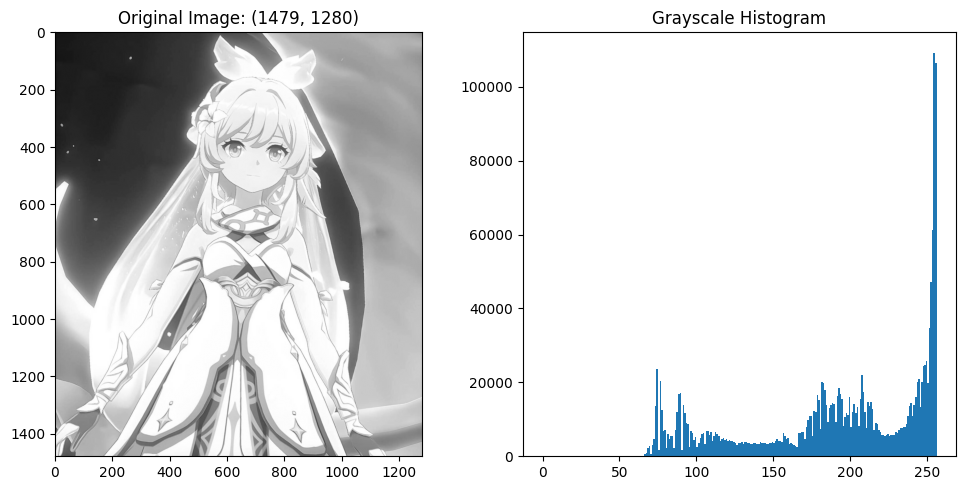

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread('../assets/images/1.jpg', cv2.IMREAD_GRAYSCALE)

# 灰度图对比
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Original Image: {img.shape}')
plt.subplot(1, 2, 2)
plt.hist(img.ravel(), 256, [0, 256])
plt.title('Grayscale Histogram')
plt.tight_layout()
plt.show()


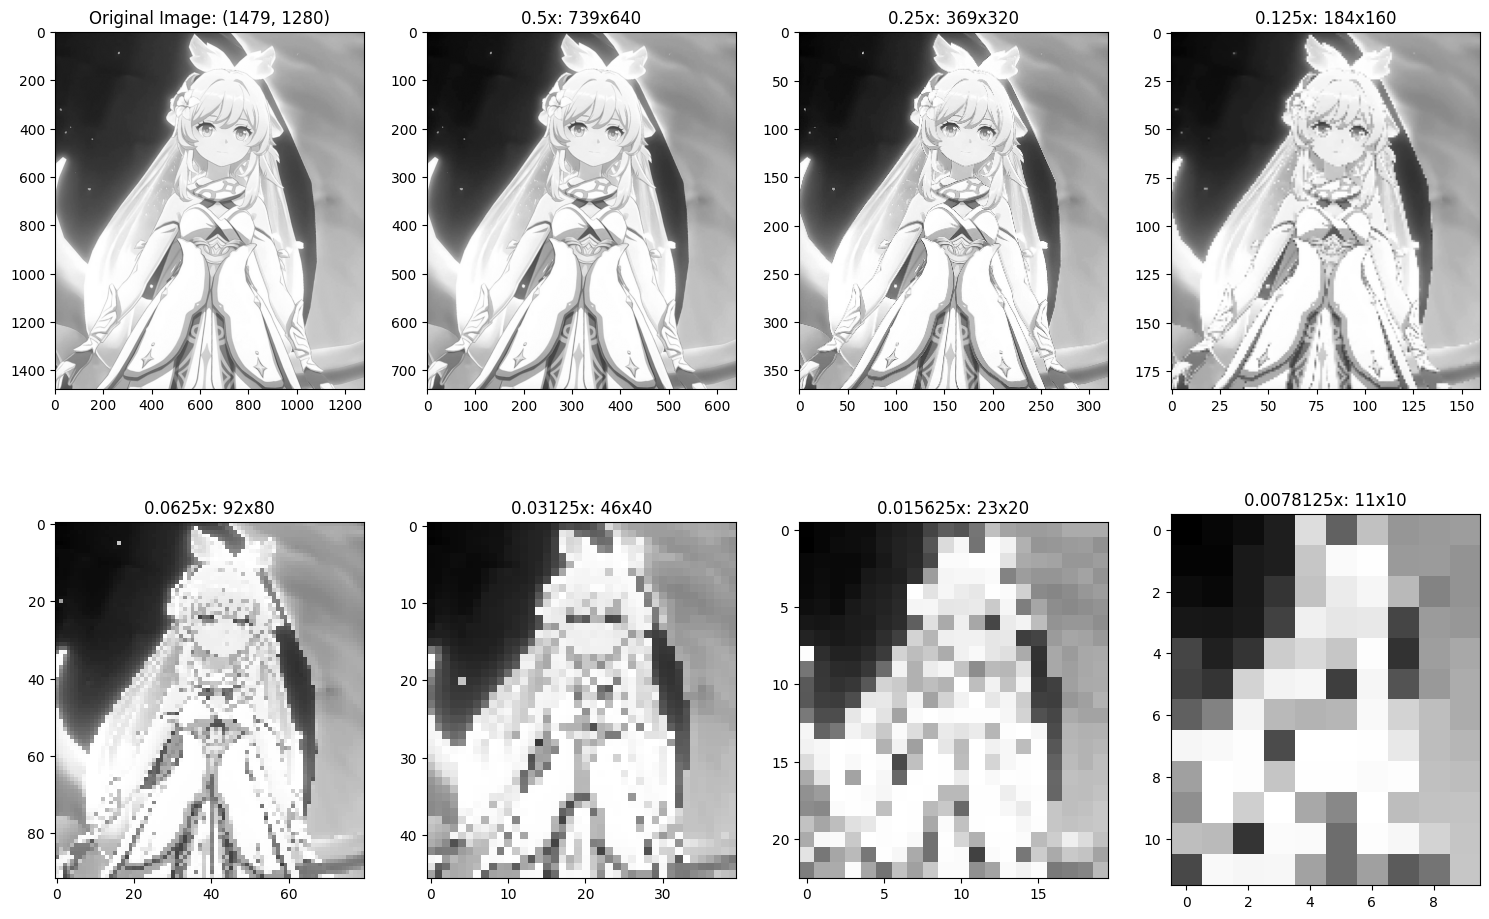

In [29]:
# 读取图像
img = cv2.imread('../assets/images/1.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(15, 10))

# 第一行
plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Original Image: {img.shape}')
plt.subplot(2, 4, 2)
plt.imshow(cv2.resize(img, None, fx=0.5, fy=0.5), cmap='gray')
plt.title(f'0.5x: {img.shape[0]//2}x{img.shape[1]//2}')
plt.subplot(2, 4, 3)
plt.imshow(cv2.resize(img, None, fx=0.25, fy=0.25), cmap='gray')
plt.title(f'0.25x: {img.shape[0]//4}x{img.shape[1]//4}')
plt.subplot(2, 4, 4)
plt.imshow(cv2.resize(img, None, fx=0.125, fy=0.125), cmap='gray')
plt.title(f'0.125x: {img.shape[0]//8}x{img.shape[1]//8}')

# 第二行
plt.subplot(2, 4, 5)
plt.imshow(cv2.resize(img, None, fx=0.0625, fy=0.0625), cmap='gray')
plt.title(f'0.0625x: {img.shape[0]//16}x{img.shape[1]//16}')
plt.subplot(2, 4, 6)
plt.imshow(cv2.resize(img, None, fx=0.03125, fy=0.03125), cmap='gray')
plt.title(f'0.03125x: {img.shape[0]//32}x{img.shape[1]//32}')
plt.subplot(2, 4, 7)
plt.imshow(cv2.resize(img, None, fx=0.015625, fy=0.015625), cmap='gray')
plt.title(f'0.015625x: {img.shape[0]//64}x{img.shape[1]//64}')
plt.subplot(2, 4, 8)
plt.imshow(cv2.resize(img, None, fx=0.0078125, fy=0.0078125), cmap='gray')
plt.title(f'0.0078125x: {img.shape[0]//128}x{img.shape[1]//128}')

plt.tight_layout()
plt.show()

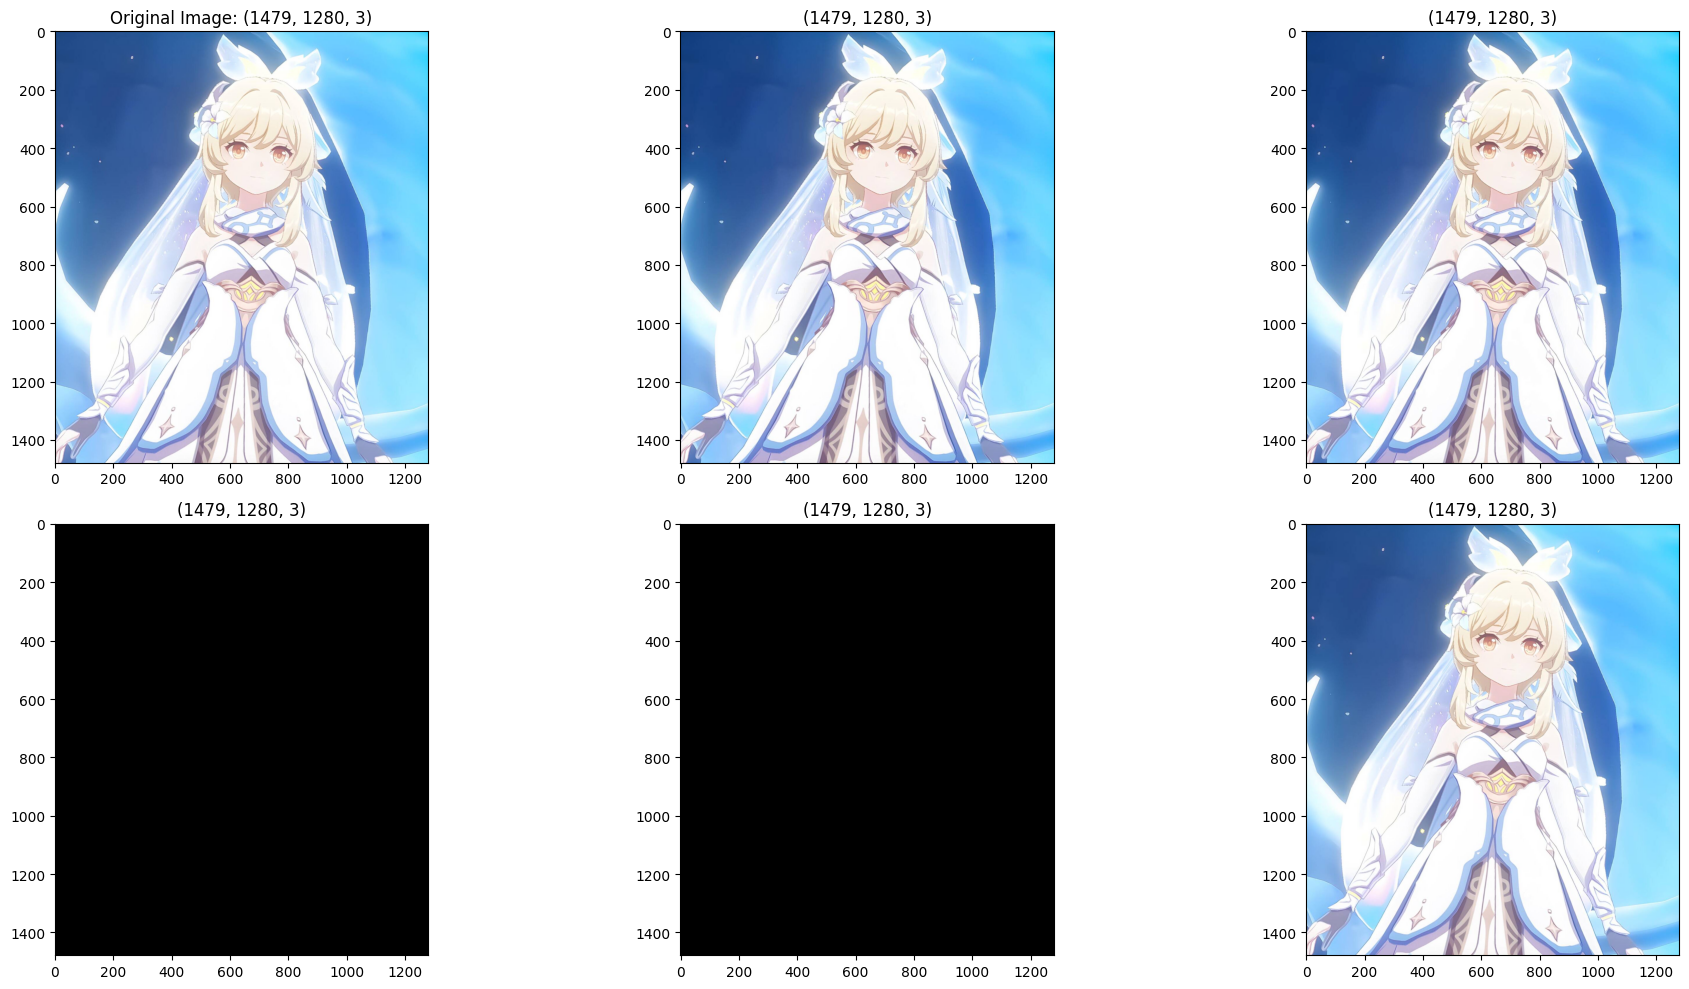

In [39]:
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 原始 MINMAX 归一化（你的原始写法）
img_2 = cv2.normalize(img_rgb, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
# MINMAX 归一化到 [0, 1] 浮点范围（适合深度学习输入）
img_3 = cv2.normalize(img_rgb, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
# L2 范数归一化（整图向量模长为 1，输出浮点）
img_4 = cv2.normalize(img_rgb.astype(np.float32), None, 1.0, 0, cv2.NORM_L2, dtype=cv2.CV_32F)
# L1 范数归一化（整图像素绝对值之和为 1）
img_5 = cv2.normalize(img_rgb.astype(np.float32), None, 1.0, 0, cv2.NORM_L1, dtype=cv2.CV_32F)
# INF 范数归一化（最大像素值缩放为 alpha=255）
img_6 = cv2.normalize(img_rgb, None, 255, 0, cv2.NORM_INF, dtype=cv2.CV_8U)

# 归一化对比
plt.figure(figsize=(20, 10))
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title(f'Original Image: {img_rgb.shape}')
plt.subplot(2, 3, 2)
plt.imshow(img_2)
plt.title(f'{img_2.shape}')
plt.subplot(2, 3, 3)
plt.imshow(img_3)
plt.title(f'{img_3.shape}')
plt.subplot(2, 3, 4)
plt.imshow(img_4)
plt.title(f'{img_4.shape}')
plt.subplot(2, 3, 5)
plt.imshow(img_5)
plt.title(f'{img_5.shape}')
plt.subplot(2, 3, 6)
plt.imshow(img_6)
plt.title(f'{img_6.shape}')
plt.tight_layout()
plt.show()


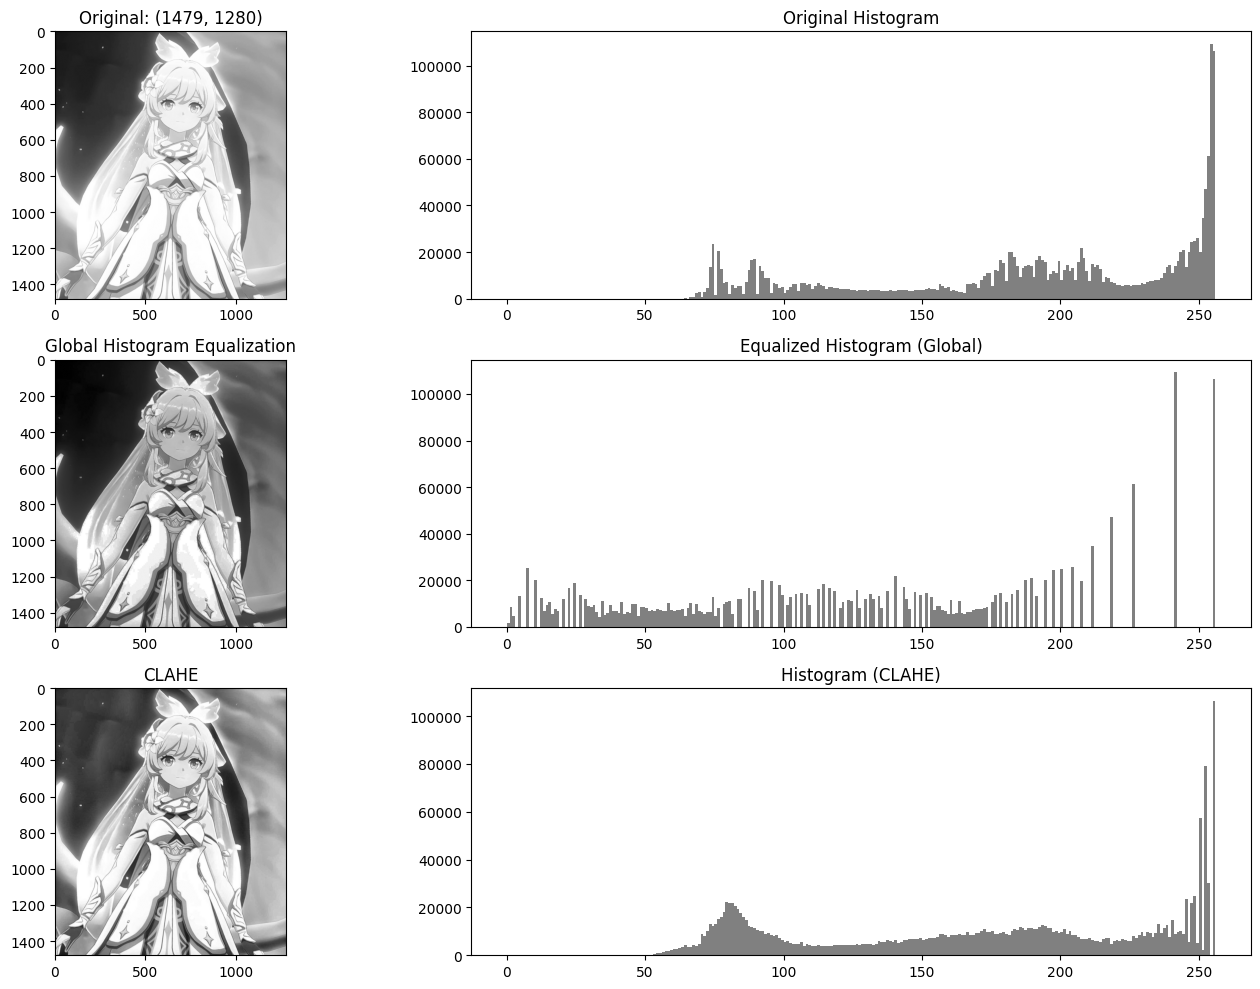

In [34]:
# 直方图均衡化

import cv2
import matplotlib.pyplot as plt

# 读取图像（灰度）
img = cv2.imread('../assets/images/1.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(15, 10))

# 原图
plt.subplot(3, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Original: {img.shape}')

# 原图直方图
plt.subplot(3, 2, 2)
plt.hist(img.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Original Histogram')

# 全局直方图均衡化
img_eq = cv2.equalizeHist(img)
plt.subplot(3, 2, 3)
plt.imshow(img_eq, cmap='gray')
plt.title('Global Histogram Equalization')

# 全局均衡化后的直方图
plt.subplot(3, 2, 4)
plt.hist(img_eq.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Equalized Histogram (Global)')

# 自适应直方图均衡化 (CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img)
plt.subplot(3, 2, 5)
plt.imshow(img_clahe, cmap='gray')
plt.title('CLAHE')

# CLAHE 后的直方图
plt.subplot(3, 2, 6)
plt.hist(img_clahe.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histogram (CLAHE)')

plt.tight_layout()
plt.show()

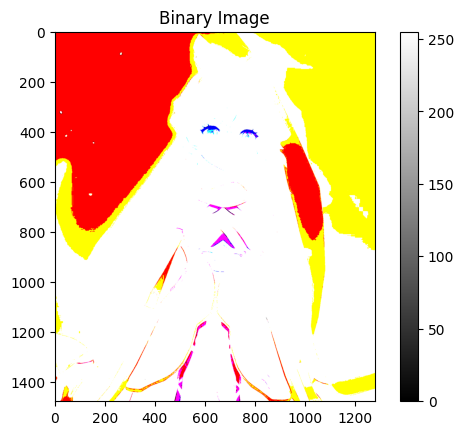

In [45]:
# 二值化
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.colorbar()
plt.title('Binary Image')
plt.show()

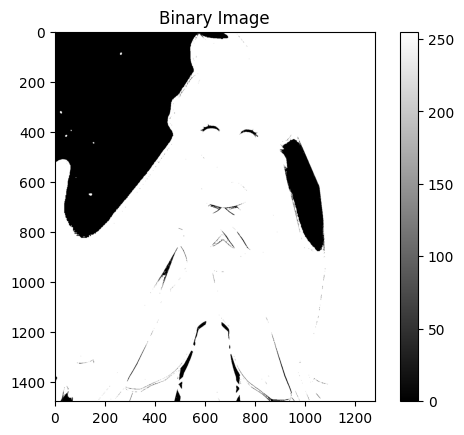

In [44]:
import cv2
import matplotlib.pyplot as plt

# 读取图像（灰度）
img = cv2.imread('../assets/images/1.jpg', cv2.IMREAD_GRAYSCALE)
ret, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')
plt.colorbar()
plt.title('Binary Image')
plt.show()

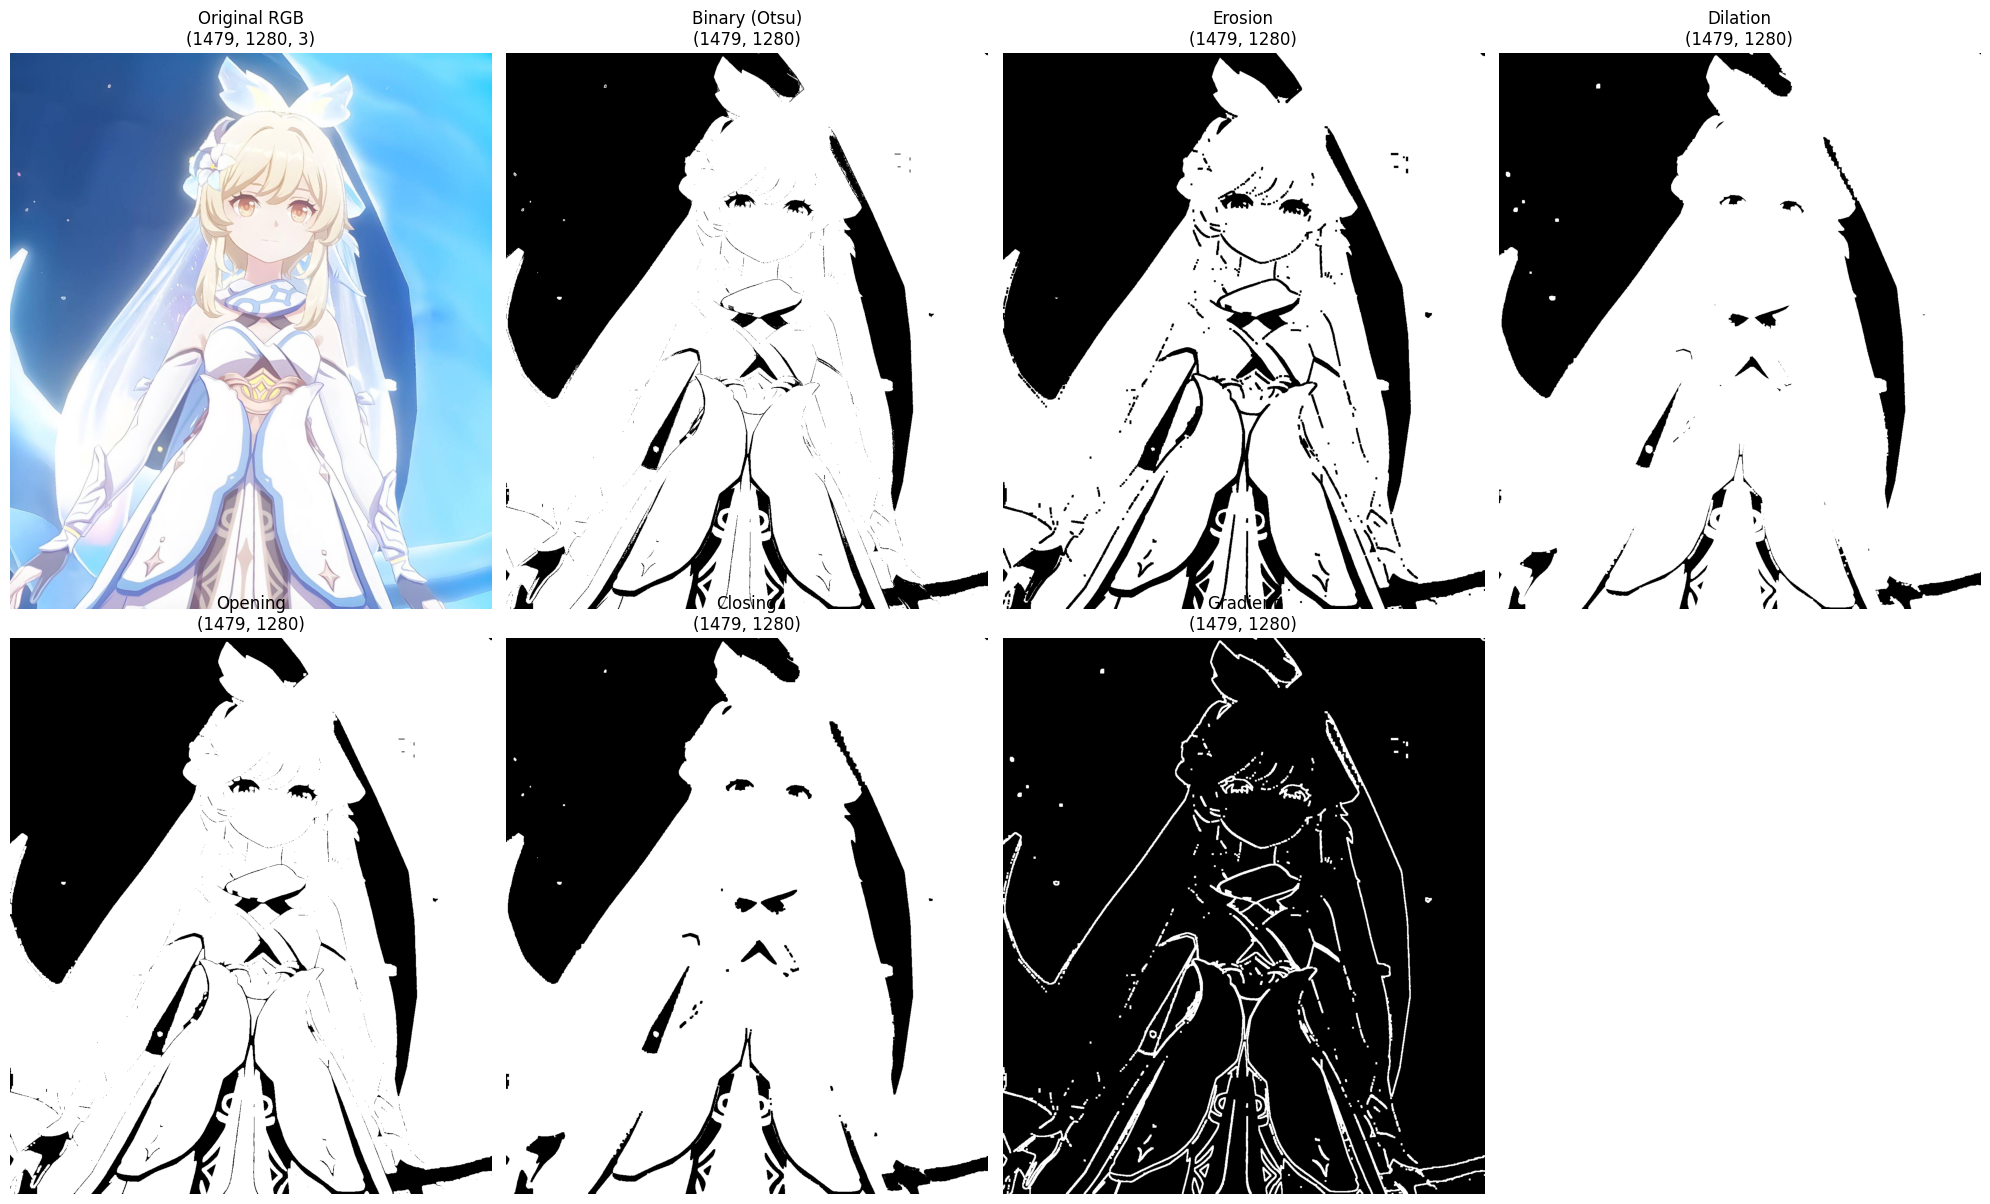

In [46]:
# 形态学操作
# 如腐蚀、膨胀、开闭运算，用于去除噪声或连接区域

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像并转换为 RGB
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 转为灰度图用于形态学操作（通常在二值图上操作，这里先灰度化）
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 二值化（Otsu 自动阈值）
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 定义结构元素（核）
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 形态学操作
img_erode = cv2.erode(binary, kernel, iterations=1)
img_dilate = cv2.dilate(binary, kernel, iterations=1)
img_open = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
img_close = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
img_gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
img_tophat = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)
img_blackhat = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)

# 可视化对比（选取7种：原图、二值图 + 5种典型形态学操作）
images = [
    (img_rgb, 'Original RGB'),
    (binary, 'Binary (Otsu)'),
    (img_erode, 'Erosion'),
    (img_dilate, 'Dilation'),
    (img_open, 'Opening'),
    (img_close, 'Closing'),
    (img_gradient, 'Gradient')
]

plt.figure(figsize=(20, 12))
for i, (img_show, title) in enumerate(images, 1):
    plt.subplot(2, 4, i)
    # 若为灰度图，使用 cmap='gray'
    if len(img_show.shape) == 2:
        plt.imshow(img_show, cmap='gray')
    else:
        plt.imshow(img_show)
    plt.title(f'{title}\n{img_show.shape}')
    plt.axis('off')

plt.tight_layout()
plt.show()

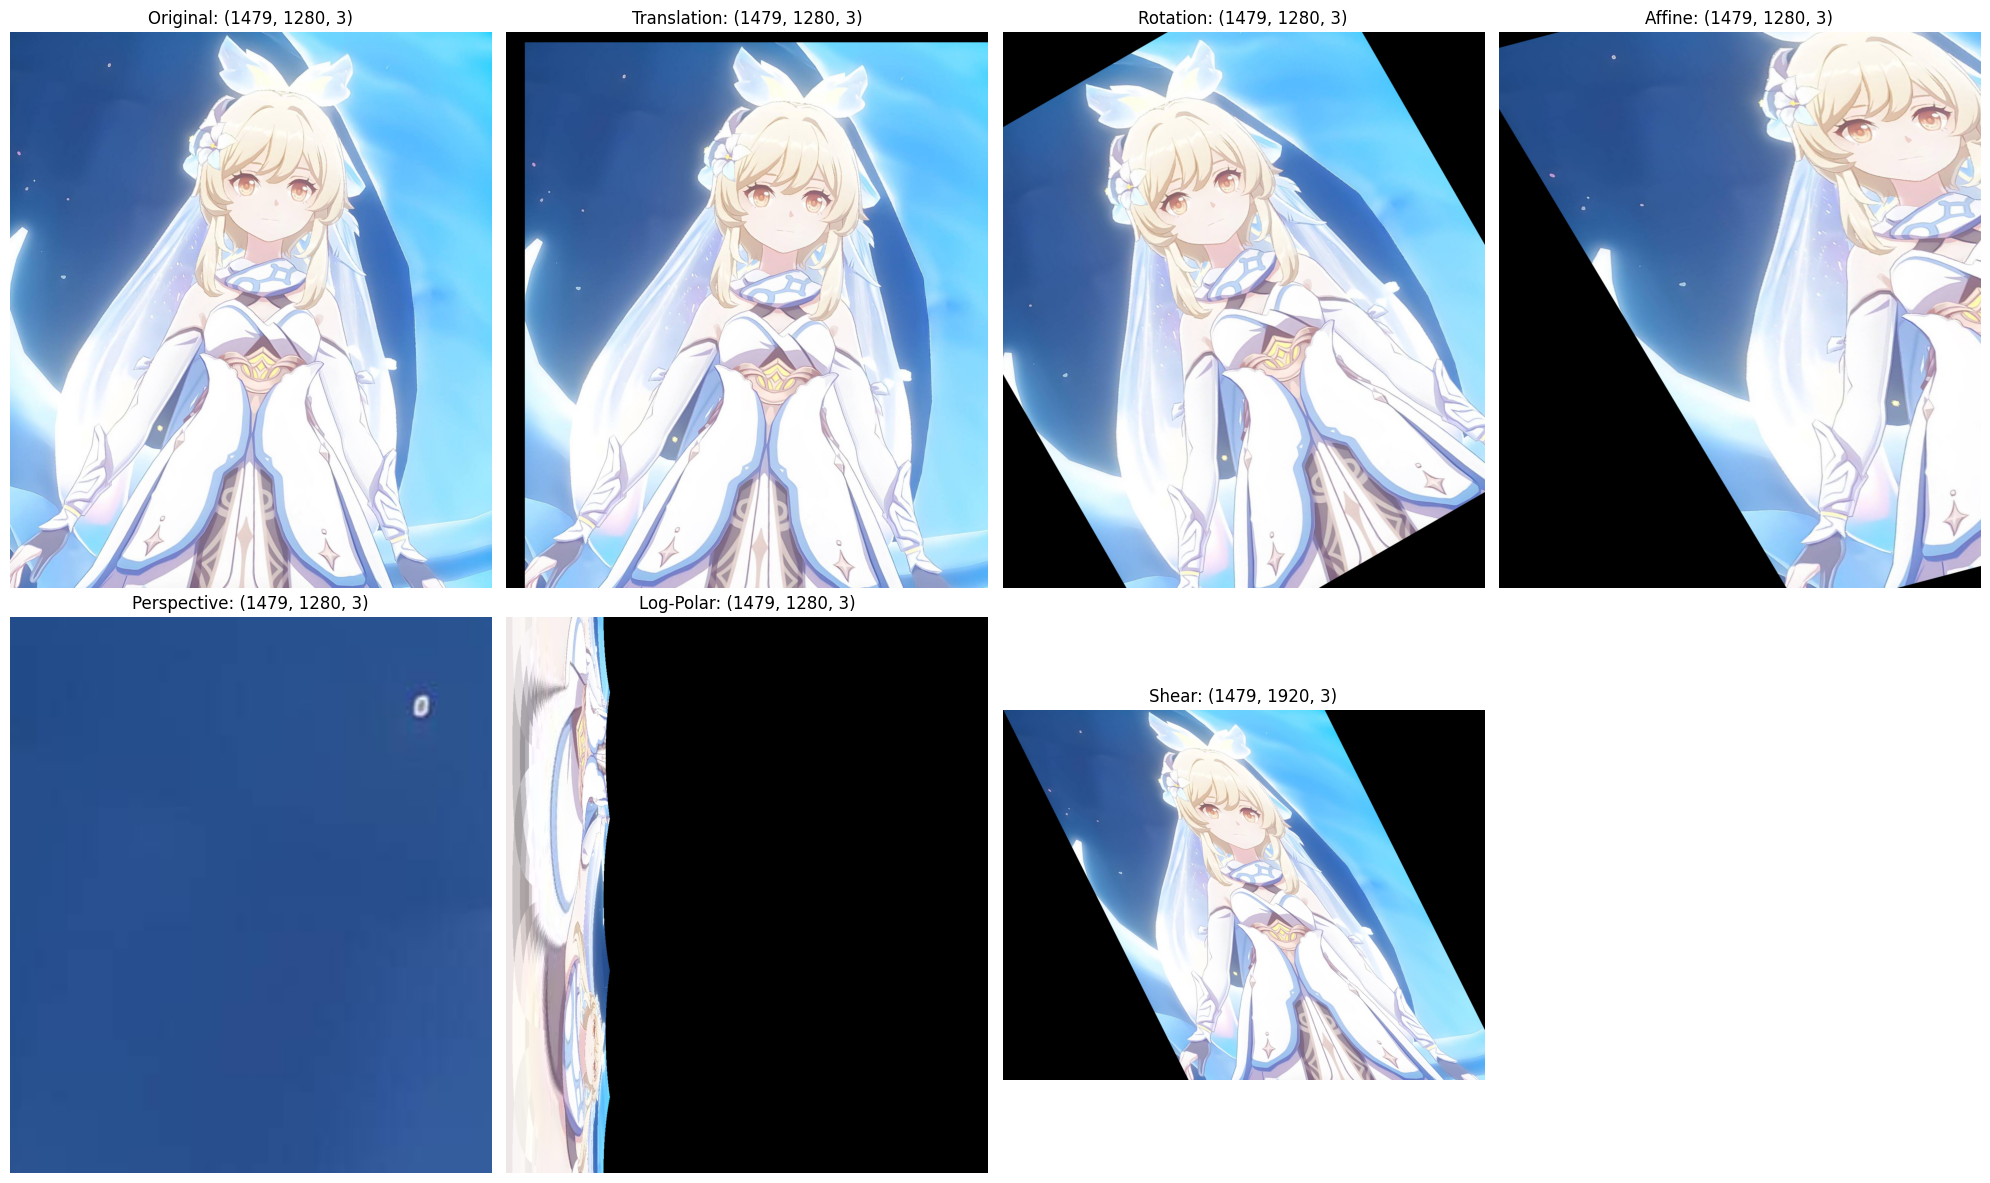

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rows, cols = img_rgb.shape[:2]

# 1. 平移变换
M_translate = np.float32([[1, 0, 50], [0, 1, 30]])
img_trans = cv2.warpAffine(img_rgb, M_translate, (cols, rows))

# 2. 旋转变换（绕中心旋转30度）
center = (cols // 2, rows // 2)
M_rotate = cv2.getRotationMatrix2D(center, 30, 1.0)
img_rotate = cv2.warpAffine(img_rgb, M_rotate, (cols, rows))

# 3. 仿射变换（三点映射）
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])
M_affine = cv2.getAffineTransform(pts1, pts2)
img_affine = cv2.warpAffine(img_rgb, M_affine, (cols, rows))

# 4. 透视变换（四点映射）
pts3 = np.float32([[50, 50], [300, 50], [50, 300], [300, 300]])
pts4 = np.float32([[0, 0], [cols, 0], [0, rows], [cols, rows]])
M_perspective = cv2.getPerspectiveTransform(pts3, pts4)
img_persp = cv2.warpPerspective(img_rgb, M_perspective, (cols, rows))

# 5. 极坐标对数变换（中心为图像中心）
img_logpolar = cv2.logPolar(
    img_rgb.astype(np.float32),
    (cols // 2, rows // 2),
    40,
    flags=cv2.WARP_FILL_OUTLIERS
).astype(np.uint8)

# 6. 剪切变换（水平剪切）
M_shear = np.float32([[1, 0.5, 0], [0, 1, 0]])
img_shear = cv2.warpAffine(img_rgb, M_shear, (int(cols * 1.5), rows))

# 可视化对比
plt.figure(figsize=(20, 12))
titles = ['Original', 'Translation', 'Rotation', 'Affine', 'Perspective', 'Log-Polar', 'Shear']
images = [img_rgb, img_trans, img_rotate, img_affine, img_persp, img_logpolar, img_shear]

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f'{titles[i]}: {images[i].shape}')
    plt.axis('off')

plt.tight_layout()
plt.show()